In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/cars.csv')

In [ ]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [ ]:
df.tail()

,brand,km_driven,fuel,owner,selling_price
8123,Hyundai,110000,Petrol,First Owner,320000
8124,Hyundai,119000,Diesel,Fourth & Above Owner,135000
8125,Maruti,120000,Diesel,First Owner,382000
8126,Tata,25000,Diesel,First Owner,290000
8127,Tata,25000,Diesel,First Owner,290000


In [ ]:
df.shape

(8128, 5)

In [ ]:
df.columns

Index(['brand', 'km_driven', 'fuel', 'owner', 'selling_price'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB


In [ ]:
df.describe()

,km_driven,selling_price
count,8.128000e+03,8.128000e+03
mean,6.981951e+04,6.382718e+05
std,5.655055e+04,8.062534e+05
min,1.000000e+00,2.999900e+04
25%,3.500000e+04,2.549990e+05
50%,6.000000e+04,4.500000e+05
75%,9.800000e+04,6.750000e+05
max,2.360457e+06,1.000000e+07


In [ ]:
df.isnull().sum()

,0
brand,0
km_driven,0
fuel,0
owner,0
selling_price,0


In [ ]:
## univariate analysis

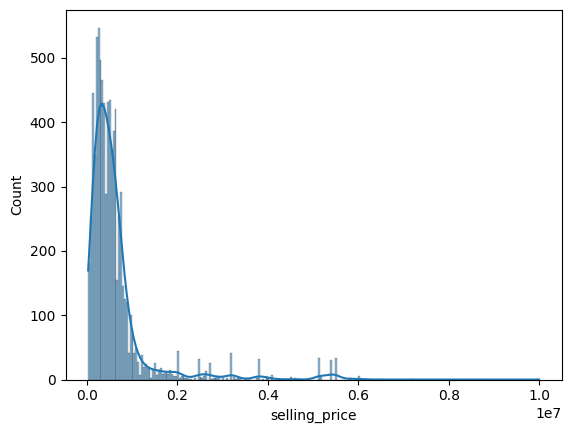

In [ ]:
sns.histplot(df['selling_price'], kde=True)
plt.show()

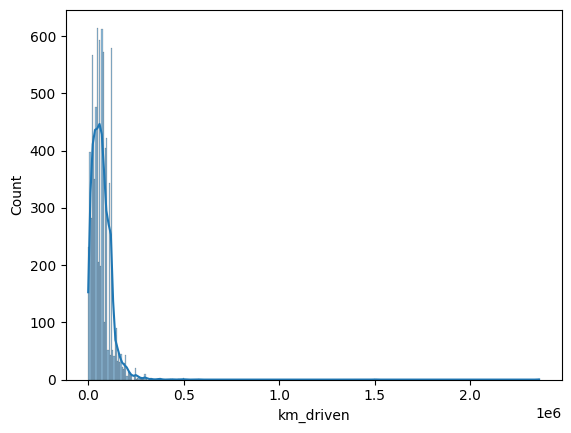

In [ ]:
sns.histplot(df['km_driven'], kde=True)
plt.show()

<Axes: xlabel='owner'>

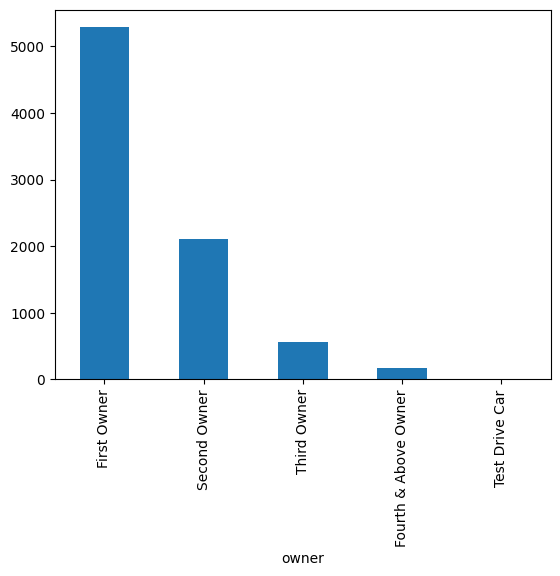

In [ ]:
df['owner'].value_counts().plot(kind='bar')

<Axes: xlabel='brand'>

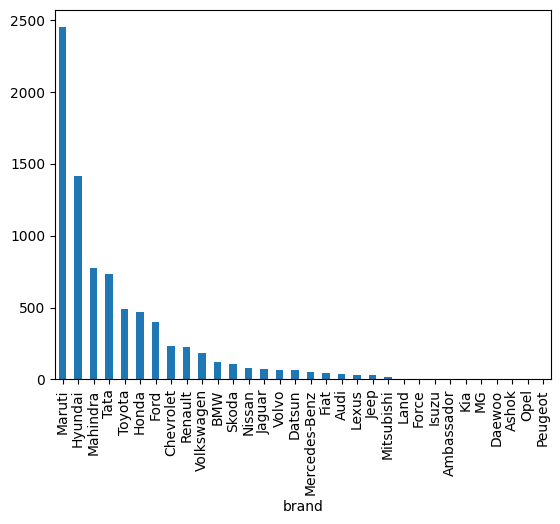

In [ ]:
df['brand'].value_counts().plot(kind='bar')


<Axes: xlabel='fuel'>

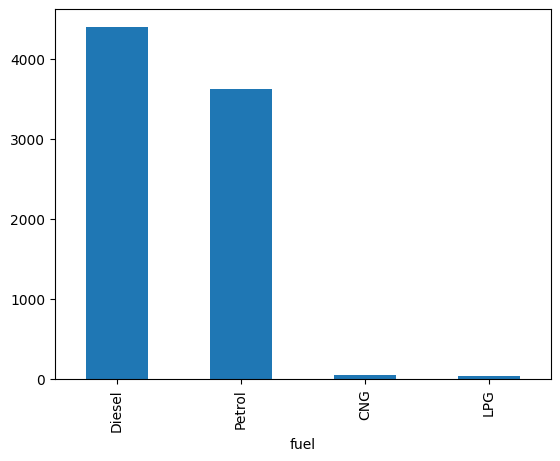

In [ ]:
df['fuel'].value_counts().plot(kind='bar')


In [ ]:
## Bivariate Analysis

<Axes: xlabel='brand'>

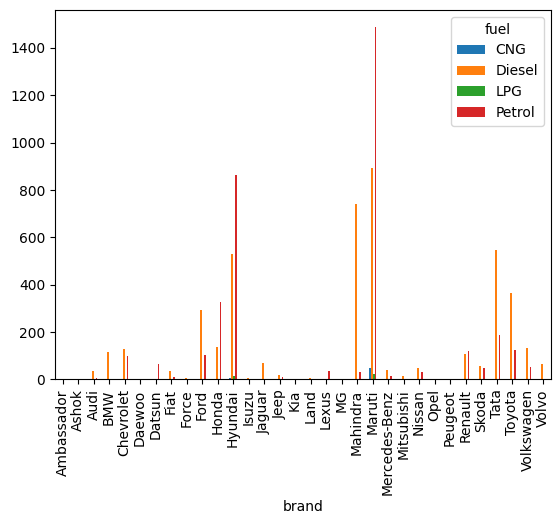

In [ ]:
pd.crosstab(df['brand'], df['fuel']).plot(kind='bar')


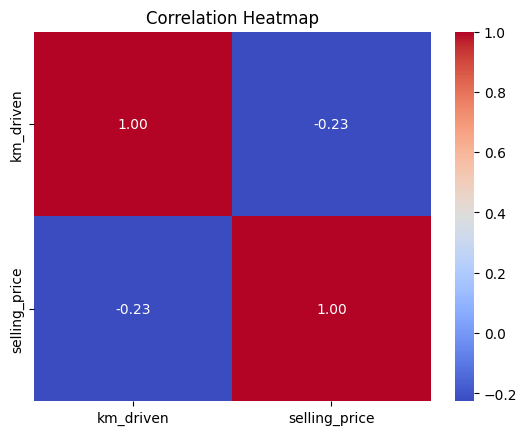

In [ ]:
corr = df[['km_driven', 'selling_price']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
corr

,km_driven,selling_price
km_driven,1.000000,-0.225534
selling_price,-0.225534,1.000000


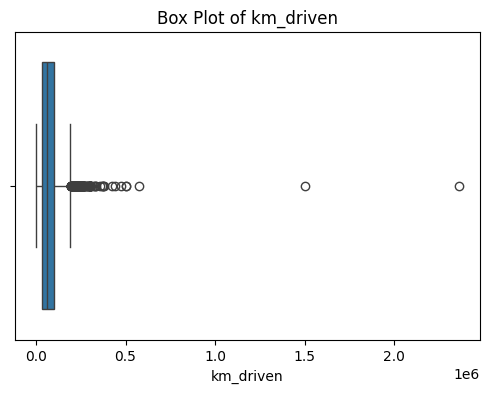

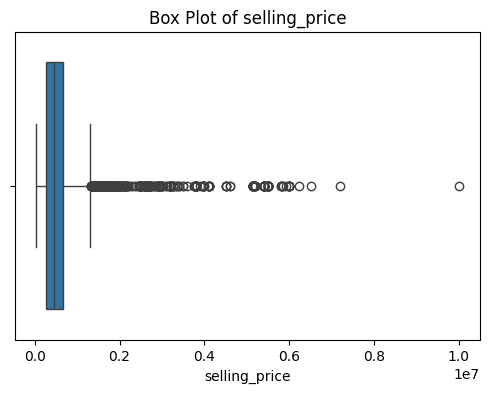

In [ ]:
num_cols = ['km_driven','selling_price']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot of {col}')
    plt.show()

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [ ]:
categorical_cols = ['brand', 'fuel', 'owner']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
df_encoded = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)


In [ ]:
df_encoded.head()

,km_driven,selling_price,brand_Ambassador,brand_Ashok,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,...,brand_Volvo,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,145500,450000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,120000,370000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,140000,158000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,127000,225000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,120000,130000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


Applying the label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['brand', 'fuel', 'owner']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])



In [ ]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,20,145500,1,0,450000
1,27,120000,1,2,370000
2,10,140000,3,4,158000
3,11,127000,1,0,225000
4,20,120000,3,0,130000


Applying the scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['km_driven', 'selling_price']

scaler = StandardScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

display(df.head())

,brand,km_driven,fuel,owner,selling_price
0,20,1.338363,1,0,-0.233529
1,27,0.887411,1,2,-0.332759
2,10,1.241098,3,4,-0.595720
3,11,1.011202,1,0,-0.512615
4,20,0.887411,3,0,-0.630451


Handle outliers using the IQR method

In [ ]:
for col in cols_to_scale:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

display(df.head())
display(df.shape)

,brand,km_driven,fuel,owner,selling_price
0,20,1.338363,1,0,-0.233529
1,27,0.887411,1,2,-0.332759
2,10,1.241098,3,4,-0.595720
3,11,1.011202,1,0,-0.512615
4,20,0.887411,3,0,-0.630451


(7358, 5)

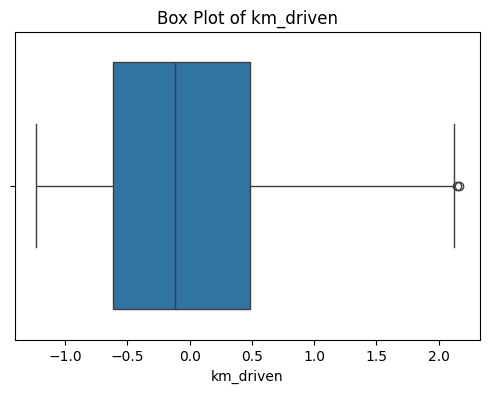

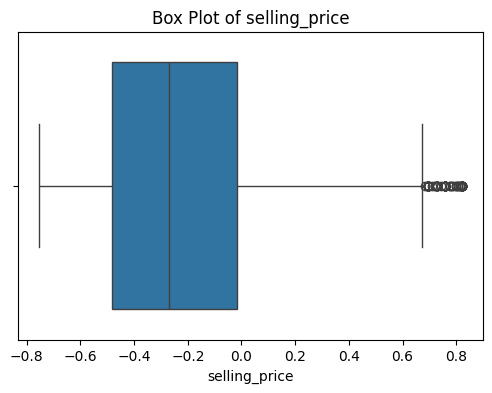

In [ ]:
num_cols = ['km_driven','selling_price']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot of {col}')
    plt.show()